In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [6]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [7]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.fc1 = nn.Linear(30, 32)
        self.drop1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(32, 16)
        self.drop2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.drop1(x)
        x = self.relu(self.fc2(x))
        x = self.drop2(x)
        x = self.sigmoid(self.fc3(x))
        return x

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

model = ANN().to(device)
print(model)

Using device: mps
ANN(
  (fc1): Linear(in_features=30, out_features=32, bias=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (drop2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


In [8]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
epochs = 100
patience = 10
best_val_loss = float('inf')
patience_counter = 0
best_weights = None

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

X_test_dev = X_test.to(device)
y_test_dev = y_test.to(device)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        preds = (outputs > 0.5).float()
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = epoch_loss / len(train_loader)
    train_acc = correct / total

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_dev)
        val_loss = criterion(val_outputs, y_test_dev).item()
        val_preds = (val_outputs > 0.5).float()
        val_acc = (val_preds == y_test_dev).sum().item() / y_test_dev.size(0)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly Stopping at epoch {epoch}")
            break

model.load_state_dict(best_weights)
print(f"\nBest Val Loss: {best_val_loss:.4f}")

Epoch   0 | Train Loss: 0.6487 | Val Loss: 0.6135 | Train Acc: 0.8505 | Val Acc: 0.9298
Epoch  10 | Train Loss: 0.1057 | Val Loss: 0.0692 | Train Acc: 0.9758 | Val Acc: 0.9737
Epoch  20 | Train Loss: 0.0644 | Val Loss: 0.0597 | Train Acc: 0.9846 | Val Acc: 0.9912
Epoch  30 | Train Loss: 0.0457 | Val Loss: 0.0590 | Train Acc: 0.9868 | Val Acc: 0.9825
Epoch  40 | Train Loss: 0.0339 | Val Loss: 0.0612 | Train Acc: 0.9912 | Val Acc: 0.9825

Early Stopping at epoch 41

Best Val Loss: 0.0582


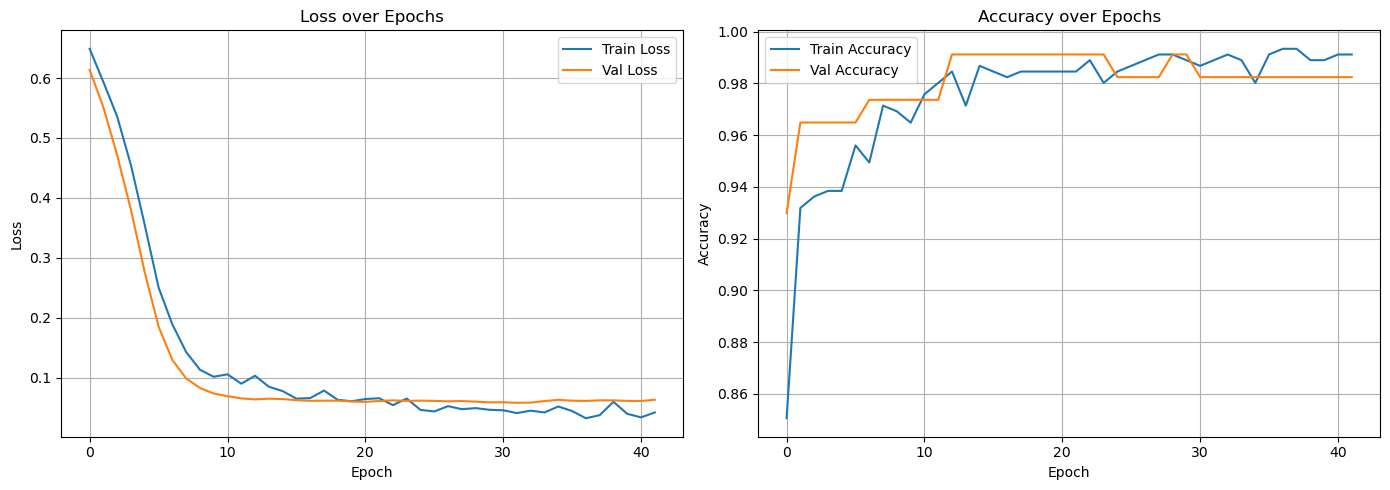

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_accuracies, label='Train Accuracy')
axes[1].plot(val_accuracies, label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [11]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test.to(device))
    y_pred = (y_pred > 0.5).int().cpu().numpy()
    y_true = y_test.int().numpy()

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Confusion Matrix:
[[42  1]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

